In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [56]:
columns = [
    'Sepal.Length',
    'Sepal.Width',
    'Petal.Length',
    'Petal.Width',
    'Species'
]

iris = pd.read_csv('iris.data', names=columns)

print(iris.head())

   Sepal.Length  Sepal.Width  Petal.Length  Petal.Width      Species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


In [57]:
print("\nDataset Shape:")
print(iris.shape)

print("\nDataset Info:")
print(iris.info())

print("\nStatistical Summary:")
print(iris.describe())

print("\nSpecies Count:")
print(iris['Species'].value_counts())


Dataset Shape:
(150, 5)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.Length  150 non-null    float64
 1   Sepal.Width   150 non-null    float64
 2   Petal.Length  150 non-null    float64
 3   Petal.Width   150 non-null    float64
 4   Species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.9 KB
None

Statistical Summary:
       Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        

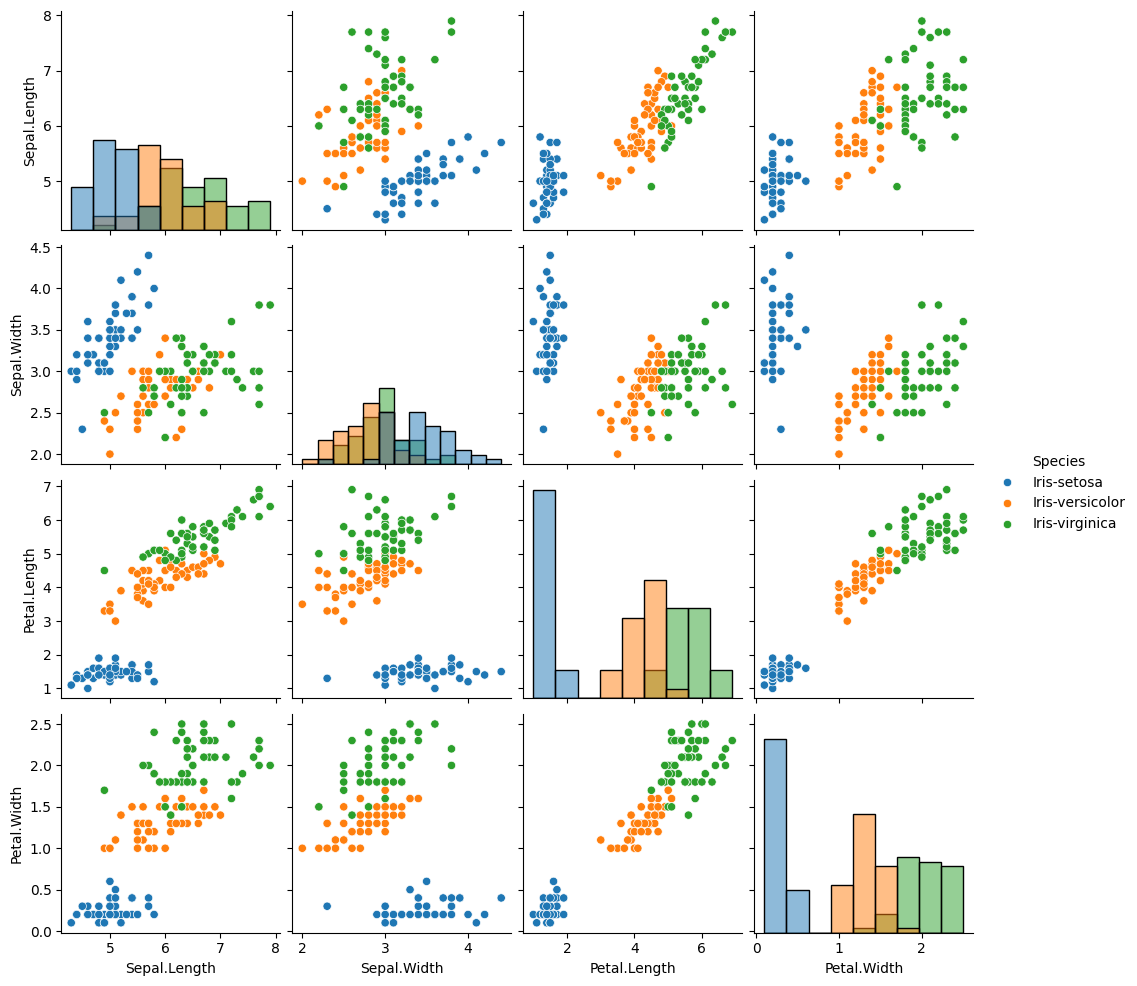

In [58]:
sns.pairplot(
    iris,
    hue='Species',
    diag_kind='hist'
)

plt.show()

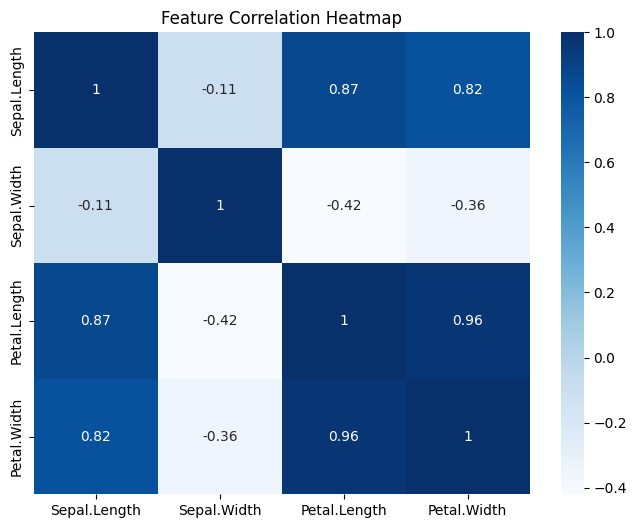

In [59]:
numeric_data = iris.drop(columns=['Species'])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap='Blues'
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [68]:
train, test = train_test_split(
    iris,
    test_size=0.2,
    random_state=42
)

train_x = train.drop(columns=['Species'])
train_y = train['Species']

test_x = test.drop(columns=['Species'])
test_y = test['Species']

In [69]:
dt_model = DecisionTreeClassifier()

dt_model.fit(train_x, train_y)

dt_pred = dt_model.predict(test_x)

dt_accuracy = accuracy_score(test_y, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 1.0


In [70]:
lr_model = LogisticRegression(max_iter=200)

lr_model.fit(train_x, train_y)

lr_pred = lr_model.predict(test_x)

lr_accuracy = accuracy_score(test_y, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 1.0


In [63]:
print("\nModel Comparison")
print("------------------------")
print("Decision Tree Accuracy:", dt_accuracy)
print("Logistic Regression Accuracy:", lr_accuracy)


Model Comparison
------------------------
Decision Tree Accuracy: 1.0
Logistic Regression Accuracy: 1.0


[[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]


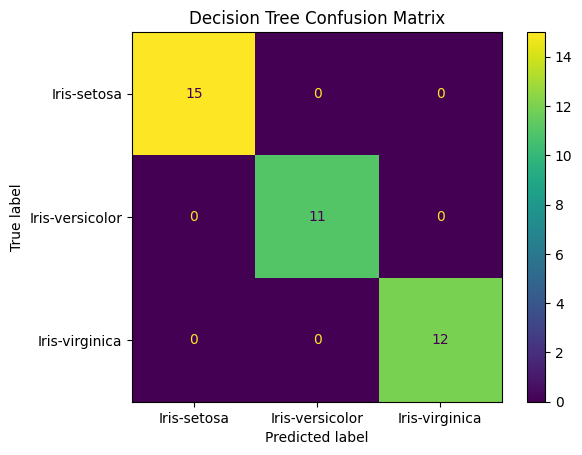

In [64]:
cm_dt = confusion_matrix(test_y, dt_pred)

print(cm_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=dt_model.classes_
)

disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

[[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]


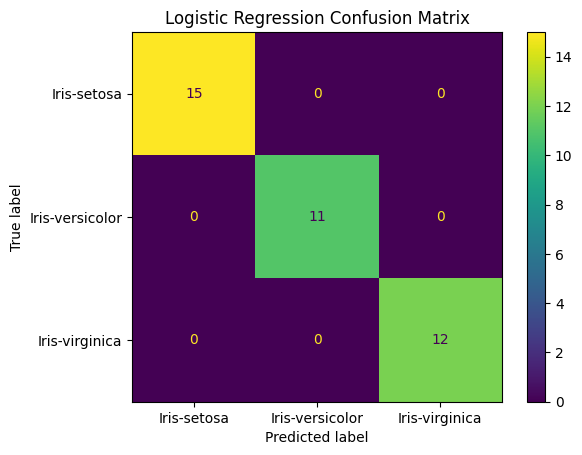

In [65]:
cm_lr = confusion_matrix(test_y, lr_pred)

print(cm_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=lr_model.classes_
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [66]:
print("Decision Tree Report")
print(classification_report(test_y, dt_pred))

print("\nLogistic Regression Report")
print(classification_report(test_y, lr_pred))

Decision Tree Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       1.00      1.00      1.00        11
 Iris-virginica       1.00      1.00      1.00        12

       accuracy                           1.00        38
      macro avg       1.00      1.00      1.00        38
   weighted avg       1.00      1.00      1.00        38


Logistic Regression Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       1.00      1.00      1.00        11
 Iris-virginica       1.00      1.00      1.00        12

       accuracy                           1.00        38
      macro avg       1.00      1.00      1.00        38
   weighted avg       1.00      1.00      1.00        38



In [67]:
print("\nEnter Flower Measurements")

sepal_length = float(input("Sepal Length: "))
sepal_width = float(input("Sepal Width: "))
petal_length = float(input("Petal Length: "))
petal_width = float(input("Petal Width: "))

new_flower = pd.DataFrame(
    [[
        sepal_length,
        sepal_width,
        petal_length,
        petal_width
    ]],
    columns=[
        'Sepal.Length',
        'Sepal.Width',
        'Petal.Length',
        'Petal.Width'
    ]
)

prediction = dt_model.predict(new_flower)

print("\nPredicted Species:", prediction[0])


Enter Flower Measurements


Sepal Length:  5
Sepal Width:  3.5
Petal Length:  4.1
Petal Width:  0.2



Predicted Species: Iris-versicolor
